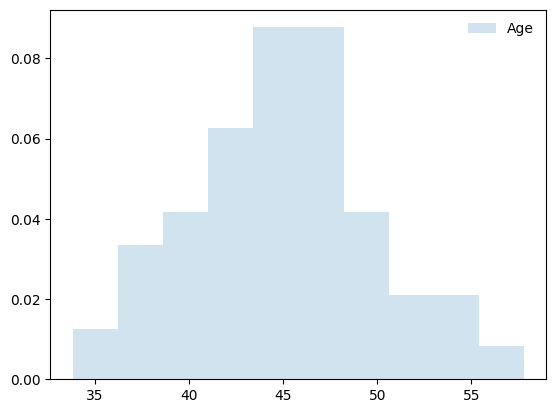

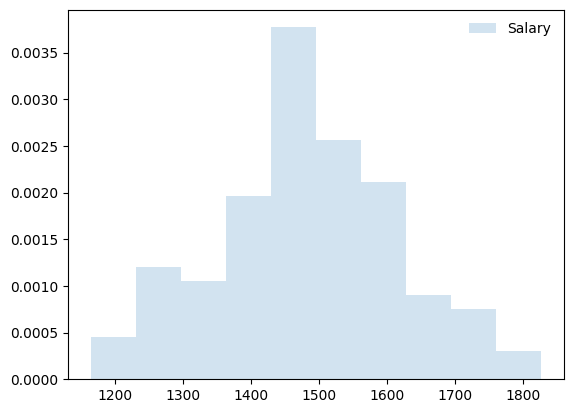

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm

sample_size = 100

## Two random historical variables
historical_age = stats.norm.rvs(loc=45, scale=5, size=sample_size)
historical_salary = stats.norm.rvs(loc=1500, scale=150, size=sample_size)

## Simulatins new values
age = list(stats.norm.rvs(loc=45, scale=5, size=sample_size))
## Mean shift
# age.extend(stats.norm.rvs(loc=43, scale=3, size=25))
# age.extend(stats.norm.rvs(loc=40, scale=2, size=25))
# age.extend(stats.norm.rvs(loc=38, scale=2, size=25))

## Variance shift - low
age.extend(stats.norm.rvs(loc=45, scale=3, size=25))
age.extend(stats.norm.rvs(loc=45, scale=2, size=25))
age.extend(stats.norm.rvs(loc=45, scale=1, size=25))

## Variance shift - high
# age.extend(stats.norm.rvs(loc=45, scale=8, size=25))
# age.extend(stats.norm.rvs(loc=45, scale=9, size=25))
# age.extend(stats.norm.rvs(loc=45, scale=10, size=25))

## Preview
fig, ax = plt.subplots(1, 1)
ax.hist(historical_age, density=True, histtype='stepfilled', alpha=0.2, label="Age")
ax.legend(loc='best', frameon=False)
plt.show()

fig, ax = plt.subplots(1, 1)
ax.hist(historical_salary, density=True, histtype='stepfilled', alpha=0.2, label="Salary")
ax.legend(loc='best', frameon=False)
plt.show()



In [ ]:
import random
import matplotlib
from matplotlib import animation
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from itertools import count
## Uses external window for visualization
%matplotlib qt

## Plots in the embedded plot pane
# %matplotlib inline

## Jupyter standard
# %matplotlib notebook

## Animation and Viz
# fig = plt.figure(figsize=(12,8))
# axes = fig.add_subplot(1,1,1)

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

x_anim, y_anim = [], []
t = range(1, len(age))

## Nowness
nowness_window_size = 50
nowness_window = []
## Drift
min_drift_window = 20
pvalue_window = []

## Age animation
def animate(i):

    if i >= len(age):
        ani.event_source.stop()

    x_anim.append(t[i])
    y_anim.append(age[i])

    ## Nowness window
    if len(nowness_window) > nowness_window_size:
        nowness_window.pop(0)
    nowness_window.append(age[i])

    ## drift analysis
    if len(nowness_window) > min_drift_window:
        ## perform drift analysis
        res = stats.ks_2samp(historical_age, nowness_window)

        ## scale for viz purposes
        pvalue_window.append(res.pvalue * 100)

        ## Viz distributions
        ax1.clear()
        ax1.set_xlim(20, 60)
        ax1.hist(historical_age, density=True, histtype='stepfilled', alpha=0.2, label="Historical Age")
        ax1.hist(nowness_window, density=True, histtype='stepfilled', alpha=0.2, label="Nowness Age")
        ax1.legend(loc="upper left")

    else:
        pvalue_window.append(0)
    
    # plt.xlim(0, len(age))
    # axes.set_ylim(0, 100)
    # plt.plot(x_anim, y_anim, scaley=True, scalex=True, color="blue")
    # plt.plot(x_anim, pvalue_window, scaley=True, scalex=True, color="red", linestyle='dashed')

    ax0.clear()
    ax0.set_xlim(0, len(age))
    ax0.set_ylim(0, 100)
    ax0.plot(x_anim, y_anim, scaley=True, scalex=True, color="blue", label="Age")
    ax0.plot(x_anim, pvalue_window, scaley=True, scalex=True, color="red", linestyle='dashed', label="p-value")
    ax0.legend(loc="upper left")

##
ani = FuncAnimation(fig=fig, func=animate, interval=300)


/var/folders/07/_bz2cvzj4bv6f1bl2w28d9nw0000gn/T/ipykernel_29570/2897532948.py:77: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = FuncAnimation(fig=fig, func=animate, interval=300)


Traceback (most recent call last):
  File "/Users/joaoreis/anaconda3/envs/nds/lib/python3.10/site-packages/matplotlib/backend_bases.py", line 1226, in _on_timer
    ret = func(*args, **kwargs)
  File "/Users/joaoreis/anaconda3/envs/nds/lib/python3.10/site-packages/matplotlib/animation.py", line 1426, in _step
    still_going = super()._step(*args)
  File "/Users/joaoreis/anaconda3/envs/nds/lib/python3.10/site-packages/matplotlib/animation.py", line 1119, in _step
    self._draw_next_frame(framedata, self._blit)
  File "/Users/joaoreis/anaconda3/envs/nds/lib/python3.10/site-packages/matplotlib/animation.py", line 1138, in _draw_next_frame
    self._draw_frame(framedata)
  File "/Users/joaoreis/anaconda3/envs/nds/lib/python3.10/site-packages/matplotlib/animation.py", line 1767, in _draw_frame
    self._drawn_artists = self._func(framedata, *self._args)
  File "/var/folders/07/_bz2cvzj4bv6f1bl2w28d9nw0000gn/T/ipykernel_29570/2897532948.py", line 38, in animate
    x_anim.append(t[i])
Inde

: 

In [12]:
## Preview
fig, ax = plt.subplots(1, 1)
ax.hist(historical_age, density=True, histtype='stepfilled', alpha=0.2, label="Historical Age")
ax.hist(nowness_window, density=True, histtype='stepfilled', alpha=0.2, label="Nowness Age")
ax.legend(loc='best', frameon=False)
plt.show()
